In [ ]:
# =============================================================================
# CELLULE 1 : IMPORTS
# =============================================================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Imports OK")

✅ Imports OK


In [8]:
# =============================================================================
# CELLULE 2 : CHARGER LES DONNÉES
# =============================================================================

import os

# ⚠️ CHEMIN COMPLET DE TON FICHIER
fichier = r"C:\Users\elham\Desktop\youtube-sentiment-analysis\data\processed\comments_for_llm.json"

# Vérifier si le fichier existe
if not os.path.exists(fichier):
    print(f"❌ Fichier non trouvé : {fichier}")
    print("\n📂 Fichiers dans le dossier :")
    dossier = r"C:\Users\elham\Desktop\youtube-sentiment-analysis\data\processed"
    if os.path.exists(dossier):
        for f in os.listdir(dossier):
            print(f"  • {f}")
    else:
        print(f"❌ Le dossier n'existe pas : {dossier}")
else:
    with open(fichier, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    
    print(f"✅ Fichier chargé : {fichier}")
    print(f"📊 Nombre de commentaires : {len(df):,}")
    print(f"📋 Colonnes : {list(df.columns)}")

✅ Fichier chargé : C:\Users\elham\Desktop\youtube-sentiment-analysis\data\processed\comments_for_llm.json
📊 Nombre de commentaires : 47,719
📋 Colonnes : ['comment_id', 'text', 'text_clean', 'tokens', 'date', 'likes', 'channel', 'lang_hint']


In [9]:
# =============================================================================
# CELLULE 3 : APERÇU DES DONNÉES
# =============================================================================

print("=" * 60)
print("👀 APERÇU DES DONNÉES")
print("=" * 60)

display(df.head(10))

👀 APERÇU DES DONNÉES


,comment_id,text,text_clean,tokens,date,likes,channel,lang_hint
0,UgxPJAXnO5KddWaG3MF4AaABAg,جيش 2026 اثبثو وجودكم ❤😂,جيش 2026 اثبثو وجودكم,"[جيش, اثبثو, وجودكم]",2026-01-02T13:52:42Z,22,Simo Sedraty,darija
1,Ugz_QMCzryTBQXSfaX94AaABAg,تفرجت فهاد الفيديو كا تلميذ و كا استاد 🤣,تفرجت فهاد الفيديو كا تلميذ و كا استاد,"[تفرجت, فهاد, الفيديو, كا, تلميذ, كا, استاد]",2025-11-20T16:53:41Z,1,Simo Sedraty,darija
2,UgyWgThaW-j2sDhmKnl4AaABAg,Knt f CP fach khrj had lvideo db Ana f 6eme,knt f cp fach khrj had lvideo db ana f 6eme,"[knt, f, cp, fach, khrj, had, lvideo, db, ana,...",2025-10-19T16:27:11Z,0,Simo Sedraty,arabizi
3,UgzabllO-GJ8LSIM_NF4AaABAg,شكون جا من 536 😂❤,شكون جا من 536,[جا],2025-08-20T21:15:48Z,1,Simo Sedraty,darija
4,UgxmgvBbH1NJFUboXkR4AaABAg,شكون جا من 2025❤😂,شكون جا من 2025,[جا],2025-07-22T00:43:55Z,2,Simo Sedraty,darija
5,UgxyXyJEDGUmoQtGRSt4AaABAg,Mazal hna2025🎉,mazal hna2025,"[mazal, hna2025]",2025-07-01T18:56:58Z,2,Simo Sedraty,arabizi
6,UgxGuCsnpY-6qPt84QB4AaABAg,Hta salit lbac 3ad jit ntferj fih 3awtani 2025...,hta salit lbac 3ad jit ntferj fih 3awtani 2025,"[hta, salit, lbac, 3ad, jit, ntferj, fih, 3awt...",2025-06-03T22:56:32Z,5,Simo Sedraty,arabizi
7,UgxPOwiYCsONTDsIqvV4AaABAg,لي كيتفرج من2025 يدير لايك,لي كيتفرج من2025 يدير لايك,"[كيتفرج, من2025, يدير, لايك]",2025-03-03T13:38:22Z,2,Simo Sedraty,darija
8,UgwNmQ-Ffr1k4L6fEih4AaABAg,كيفاش دازت 10 سنين أنا كنت مزالة صغيرة كبرت وه...,كيفاش دازت 10 سنين انا كنت مزاله صغيره كبرت وه...,"[كيفاش, دازت, سنين, انا, كنت, مزاله, صغيره, كب...",2025-02-09T21:48:49Z,0,Simo Sedraty,darija
9,UgzbmSAFrdlvFtq_wTR4AaABAg,10 سنين على الفيديو 😢,10 سنين علي الفيديو,"[سنين, علي, الفيديو]",2025-02-02T00:36:40Z,1,Simo Sedraty,darija


In [10]:
# =============================================================================
# CELLULE 4 : STATISTIQUES DE BASE
# =============================================================================

print("=" * 60)
print("📈 STATISTIQUES DE BASE")
print("=" * 60)

total = len(df)
uniques = df['comment_id'].nunique() if 'comment_id' in df.columns else total
doublons = total - uniques
vides = df['text_clean'].isna().sum() + (df['text_clean'] == '').sum()

stats_base = {
    'Total commentaires': f"{total:,}",
    'Commentaires uniques': f"{uniques:,}",
    'Doublons': f"{doublons:,}",
    'Commentaires vides': f"{vides:,}",
    'Colonnes': f"{len(df.columns)}"
}

for k, v in stats_base.items():
    print(f"  • {k}: {v}")

📈 STATISTIQUES DE BASE
  • Total commentaires: 47,719
  • Commentaires uniques: 47,719
  • Doublons: 0
  • Commentaires vides: 0
  • Colonnes: 8


In [11]:
# =============================================================================
# CELLULE 5 : PRÉPARER LES COLONNES POUR L'ANALYSE
# =============================================================================

# Longueur en caractères
df['longueur_chars'] = df['text_clean'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Longueur en mots (depuis tokens si disponible)
if 'tokens' in df.columns:
    df['longueur_mots'] = df['tokens'].apply(lambda x: len(x) if isinstance(x, list) else 0)
else:
    df['longueur_mots'] = df['text_clean'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# Date
if 'date' in df.columns:
    df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
    df['annee'] = df['date_parsed'].dt.year
    df['mois'] = df['date_parsed'].dt.month
    df['jour_semaine'] = df['date_parsed'].dt.day_name()

print("✅ Colonnes préparées")

✅ Colonnes préparées


In [12]:
# =============================================================================
# CELLULE 6 : STATISTIQUES DE LONGUEUR
# =============================================================================

print("=" * 60)
print("📏 STATISTIQUES DE LONGUEUR")
print("=" * 60)

print("\n📝 Longueur en CARACTÈRES :")
print(f"  • Moyenne   : {df['longueur_chars'].mean():.1f}")
print(f"  • Médiane   : {df['longueur_chars'].median():.1f}")
print(f"  • Minimum   : {df['longueur_chars'].min()}")
print(f"  • Maximum   : {df['longueur_chars'].max()}")

print("\n📝 Longueur en MOTS :")
print(f"  • Moyenne   : {df['longueur_mots'].mean():.1f}")
print(f"  • Médiane   : {df['longueur_mots'].median():.1f}")
print(f"  • Minimum   : {df['longueur_mots'].min()}")
print(f"  • Maximum   : {df['longueur_mots'].max()}")

📏 STATISTIQUES DE LONGUEUR

📝 Longueur en CARACTÈRES :
  • Moyenne   : 48.8
  • Médiane   : 34.0
  • Minimum   : 2
  • Maximum   : 408

📝 Longueur en MOTS :
  • Moyenne   : 8.1
  • Médiane   : 6.0
  • Minimum   : 1
  • Maximum   : 66


In [15]:
# =============================================================================
# CELLULE 7 : STATISTIQUES PAR COLONNE
# =============================================================================

print("=" * 60)
print("📊 STATISTIQUES PAR COLONNE")
print("=" * 60)

# Langues
if 'lang_hint' in df.columns:
    print("\n🌍 LANGUES :")
    lang_counts = df['lang_hint'].value_counts()
    for lang, count in lang_counts.items():
        pct = count / len(df) * 100
        print(f"  • {lang}: {count:,} ({pct:.1f}%)")


# Likes
if 'likes' in df.columns:
    print(f"\n👍 LIKES :")
    print(f"  • Moyenne   : {df['likes'].mean():.1f}")
    print(f"  • Maximum   : {df['likes'].max()}")
    print(f"  • 0 likes   : {(df['likes'] == 0).sum():,} ({(df['likes'] == 0).sum()/len(df)*100:.1f}%)")

# Dates
if 'annee' in df.columns:
    print(f"\n📅 DATES :")
    for annee, count in df['annee'].value_counts().sort_index().items():
        pct = count / len(df) * 100
        print(f"  • {int(annee)}: {count:,} ({pct:.1f}%)")

📊 STATISTIQUES PAR COLONNE

🌍 LANGUES :
  • darija: 26,605 (55.8%)
  • arabizi: 19,289 (40.4%)
  • mixed: 1,825 (3.8%)

👍 LIKES :
  • Moyenne   : 4.5
  • Maximum   : 7620
  • 0 likes   : 30,476 (63.9%)

📅 DATES :
  • 2025: 29,254 (61.3%)
  • 2026: 18,180 (38.1%)


In [16]:
# =============================================================================
# CELLULE 8 : TOP MOTS
# =============================================================================

print("=" * 60)
print("📝 TOP 20 MOTS LES PLUS FRÉQUENTS")
print("=" * 60)

# Extraire tous les mots depuis tokens
if 'tokens' in df.columns:
    all_tokens = []
    for tokens in df['tokens']:
        if isinstance(tokens, list):
            all_tokens.extend(tokens)
    
    word_counts = Counter(all_tokens)
    
    print("\n")
    for i, (mot, count) in enumerate(word_counts.most_common(20), 1):
        print(f"  {i:2}. {mot}: {count:,}")
else:
    print("⚠️ Colonne 'tokens' non trouvée")

📝 TOP 20 MOTS LES PLUS FRÉQUENTS


   1. الله: 2,972
   2. علي: 2,855
   3. هه: 2,599
   4. hh: 2,065
   5. f: 1,844
   6. had: 1,781
   7. li: 1,651
   8. انا: 1,624
   9. o: 1,587
  10. l: 1,547
  11. simo: 1,521
  12. لا: 1,283
  13. ما: 1,166
  14. 3la: 1,152
  15. واحد: 1,117
  16. w: 1,048
  17. ana: 1,031
  18. مع: 1,004
  19. mn: 989
  20. مروان: 911


C:\Users\elham\AppData\Local\Temp\ipykernel_1700\3141589577.py:148: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\3141589577.py:148: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\3141589577.py:148: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\3141589577.py:148: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\3141589577.py:148: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\3141589577.py:148: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Lo

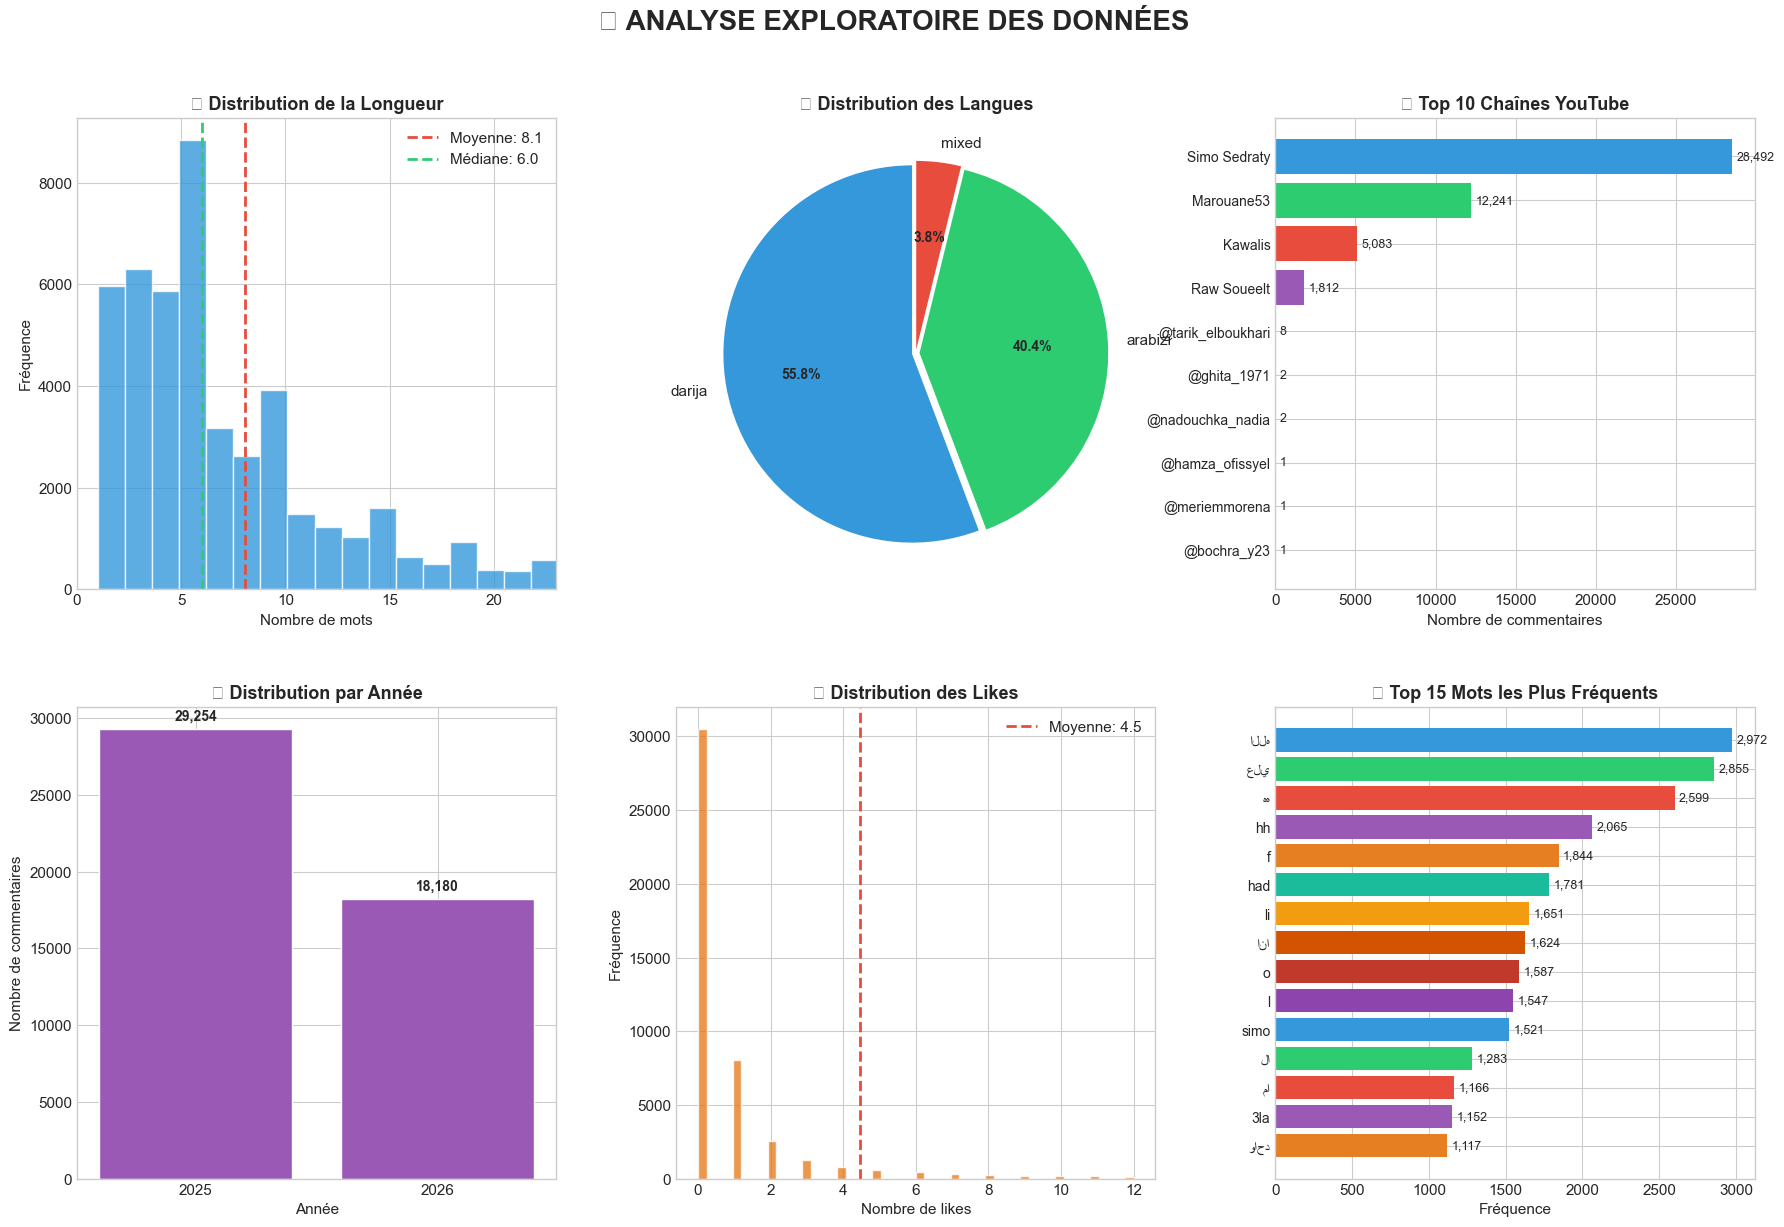


✅ Figure sauvegardée : reports/figures/eda_global.png


In [17]:
# =============================================================================
# CELLULE 9 : GRANDE FIGURE (6 GRAPHIQUES EN 1)
# =============================================================================

# Couleurs
COLORS = {
    'primary': '#3498db',
    'secondary': '#2ecc71', 
    'accent': '#e74c3c',
    'neutral': '#95a5a6',
    'purple': '#9b59b6',
    'orange': '#e67e22'
}

# Palette pour les barres
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#e67e22', 
           '#1abc9c', '#f39c12', '#d35400', '#c0392b', '#8e44ad']

# Créer la figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📊 ANALYSE EXPLORATOIRE DES DONNÉES', fontsize=20, fontweight='bold', y=1.02)

# ============================================
# GRAPHIQUE 1 : Distribution de la longueur (mots)
# ============================================
ax1 = axes[0, 0]
ax1.hist(df['longueur_mots'], bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.8)
ax1.axvline(df['longueur_mots'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2, 
            label=f"Moyenne: {df['longueur_mots'].mean():.1f}")
ax1.axvline(df['longueur_mots'].median(), color=COLORS['secondary'], linestyle='--', linewidth=2,
            label=f"Médiane: {df['longueur_mots'].median():.1f}")
ax1.set_xlabel('Nombre de mots', fontsize=11)
ax1.set_ylabel('Fréquence', fontsize=11)
ax1.set_title('📏 Distribution de la Longueur', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_xlim(0, df['longueur_mots'].quantile(0.95))  # Éviter les outliers

# ============================================
# GRAPHIQUE 2 : Distribution des langues
# ============================================
ax2 = axes[0, 1]
if 'lang_hint' in df.columns:
    lang_counts = df['lang_hint'].value_counts()
    colors_pie = palette[:len(lang_counts)]
    wedges, texts, autotexts = ax2.pie(
        lang_counts.values, 
        labels=lang_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        explode=[0.02] * len(lang_counts),
        shadow=False,
        startangle=90
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    ax2.set_title('🌍 Distribution des Langues', fontsize=13, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Pas de colonne\n"lang_hint"', ha='center', va='center', fontsize=14)
    ax2.set_title('🌍 Distribution des Langues', fontsize=13, fontweight='bold')

# ============================================
# GRAPHIQUE 3 : Top 10 Chaînes
# ============================================
ax3 = axes[0, 2]
if 'channel' in df.columns:
    top_channels = df['channel'].value_counts().head(10)
    bars = ax3.barh(range(len(top_channels)), top_channels.values, color=palette[:len(top_channels)])
    ax3.set_yticks(range(len(top_channels)))
    ax3.set_yticklabels(top_channels.index, fontsize=10)
    ax3.invert_yaxis()
    ax3.set_xlabel('Nombre de commentaires', fontsize=11)
    ax3.set_title('📺 Top 10 Chaînes YouTube', fontsize=13, fontweight='bold')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, val) in enumerate(zip(bars, top_channels.values)):
        ax3.text(val + max(top_channels.values)*0.01, i, f'{val:,}', va='center', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Pas de colonne\n"channel"', ha='center', va='center', fontsize=14)
    ax3.set_title('📺 Top 10 Chaînes YouTube', fontsize=13, fontweight='bold')

# ============================================
# GRAPHIQUE 4 : Distribution par année
# ============================================
ax4 = axes[1, 0]
if 'annee' in df.columns:
    annee_counts = df['annee'].value_counts().sort_index()
    bars = ax4.bar(annee_counts.index.astype(int), annee_counts.values, color=COLORS['purple'], edgecolor='white')
    ax4.set_xlabel('Année', fontsize=11)
    ax4.set_ylabel('Nombre de commentaires', fontsize=11)
    ax4.set_title('📅 Distribution par Année', fontsize=13, fontweight='bold')
    ax4.set_xticks(annee_counts.index.astype(int))
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, annee_counts.values):
        ax4.text(bar.get_x() + bar.get_width()/2, val + max(annee_counts.values)*0.02, 
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Pas de colonne\n"date"', ha='center', va='center', fontsize=14)
    ax4.set_title('📅 Distribution par Année', fontsize=13, fontweight='bold')

# ============================================
# GRAPHIQUE 5 : Distribution des likes
# ============================================
ax5 = axes[1, 1]
if 'likes' in df.columns:
    # Limiter aux likes < 95e percentile pour mieux voir
    likes_filtered = df['likes'][df['likes'] <= df['likes'].quantile(0.95)]
    ax5.hist(likes_filtered, bins=50, color=COLORS['orange'], edgecolor='white', alpha=0.8)
    ax5.axvline(df['likes'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
                label=f"Moyenne: {df['likes'].mean():.1f}")
    ax5.set_xlabel('Nombre de likes', fontsize=11)
    ax5.set_ylabel('Fréquence', fontsize=11)
    ax5.set_title('👍 Distribution des Likes', fontsize=13, fontweight='bold')
    ax5.legend(loc='upper right')
else:
    ax5.text(0.5, 0.5, 'Pas de colonne\n"likes"', ha='center', va='center', fontsize=14)
    ax5.set_title('👍 Distribution des Likes', fontsize=13, fontweight='bold')

# ============================================
# GRAPHIQUE 6 : Top 15 Mots
# ============================================
ax6 = axes[1, 2]
if 'tokens' in df.columns:
    all_tokens = []
    for tokens in df['tokens']:
        if isinstance(tokens, list):
            all_tokens.extend(tokens)
    
    word_counts = Counter(all_tokens)
    top_words = dict(word_counts.most_common(15))
    
    bars = ax6.barh(range(len(top_words)), list(top_words.values()), color=palette[:len(top_words)])
    ax6.set_yticks(range(len(top_words)))
    ax6.set_yticklabels(list(top_words.keys()), fontsize=10)
    ax6.invert_yaxis()
    ax6.set_xlabel('Fréquence', fontsize=11)
    ax6.set_title('📝 Top 15 Mots les Plus Fréquents', fontsize=13, fontweight='bold')
    
    # Ajouter les valeurs
    for i, (bar, val) in enumerate(zip(bars, top_words.values())):
        ax6.text(val + max(top_words.values())*0.01, i, f'{val:,}', va='center', fontsize=9)
else:
    ax6.text(0.5, 0.5, 'Pas de colonne\n"tokens"', ha='center', va='center', fontsize=14)
    ax6.set_title('📝 Top 15 Mots', fontsize=13, fontweight='bold')

# Ajuster l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.25, wspace=0.25)

# Sauvegarder
plt.savefig('../reports/figures/eda_global.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Figure sauvegardée : reports/figures/eda_global.png")

C:\Users\elham\AppData\Local\Temp\ipykernel_1700\621289174.py:34: UserWarning: Glyph 9729 (\N{CLOUD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\621289174.py:34: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\621289174.py:35: UserWarning: Glyph 9729 (\N{CLOUD}) missing from font(s) Arial.
  plt.savefig('../reports/figures/wordcloud.png', dpi=200, bbox_inches='tight', facecolor='white')
C:\Users\elham\AppData\Local\Temp\ipykernel_1700\621289174.py:35: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('../reports/figures/wordcloud.png', dpi=200, bbox_inches='tight', facecolor='white')
c:\Users\elham\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9729 (\N{CLOUD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, *

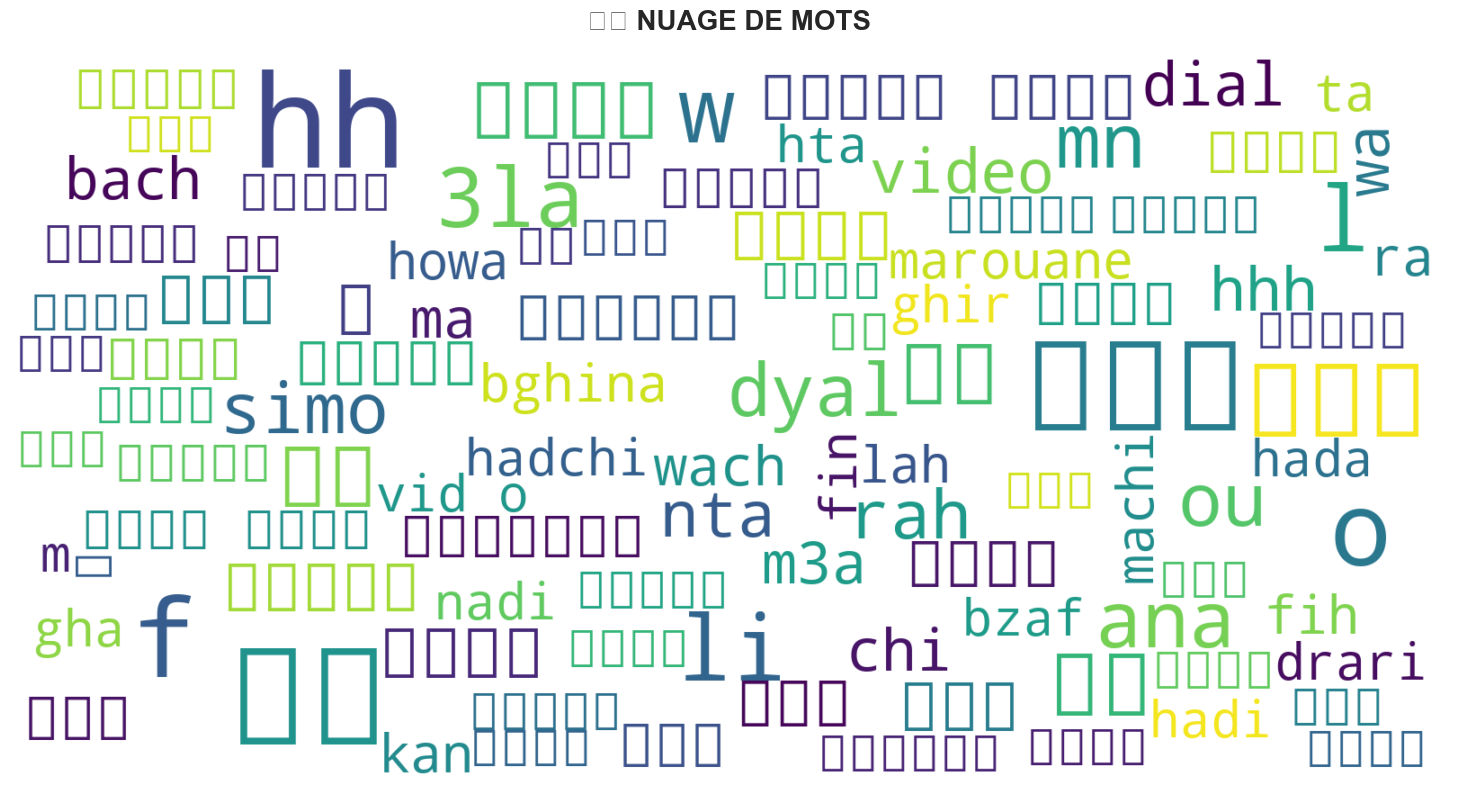


✅ WordCloud sauvegardé : reports/figures/wordcloud.png


In [19]:
# =============================================================================
# CELLULE 10 : WORDCLOUD
# =============================================================================

try:
    from wordcloud import WordCloud
    
    if 'tokens' in df.columns:
        # Joindre tous les tokens
        all_tokens = []
        for tokens in df['tokens']:
            if isinstance(tokens, list):
                all_tokens.extend(tokens)
        
        text_combined = ' '.join(all_tokens)
        
        # Créer WordCloud
        wordcloud = WordCloud(
            width=1600,
            height=800,
            background_color='white',
            max_words=100,
            colormap='viridis',
            min_font_size=10,
            max_font_size=150
        ).generate(text_combined)
        
        # Afficher
        fig, ax = plt.subplots(figsize=(16, 8))
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title('☁️ NUAGE DE MOTS', fontsize=20, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig('../reports/figures/wordcloud.png', dpi=200, bbox_inches='tight', facecolor='white')
        plt.show()
        
        print("\n✅ WordCloud sauvegardé : reports/figures/wordcloud.png")
    else:
        print("⚠️ Colonne 'tokens' non trouvée")
        
except ImportError:
    print("⚠️ Pour le WordCloud, installe : pip install wordcloud")

In [21]:
# =============================================================================
# CELLULE 12 : EXEMPLES DE COMMENTAIRES
# =============================================================================

print("\n")
print("=" * 70)
print("💬 EXEMPLES DE COMMENTAIRES")
print("=" * 70)

# Commentaires les plus longs
print("\n📏 5 COMMENTAIRES LES PLUS LONGS :")
print("-" * 50)
top_long = df.nlargest(5, 'longueur_mots')
for i, row in top_long.iterrows():
    text = row['text_clean'][:100] + "..." if len(str(row['text_clean'])) > 100 else row['text_clean']
    print(f"  [{row['longueur_mots']} mots] {text}")

# Commentaires les plus likés
if 'likes' in df.columns:
    print("\n👍 5 COMMENTAIRES LES PLUS LIKÉS :")
    print("-" * 50)
    top_liked = df.nlargest(5, 'likes')
    for i, row in top_liked.iterrows():
        text = row['text_clean'][:80] + "..." if len(str(row['text_clean'])) > 80 else row['text_clean']
        print(f"  [{row['likes']} likes] {text}")





💬 EXEMPLES DE COMMENTAIRES

📏 5 COMMENTAIRES LES PLUS LONGS :
--------------------------------------------------
  [66 mots] عفوا مع كل احترامي لك يا فنان وكلامك علي صواب خليونا من جيران ولا جهه اخري اذا كانت هاد امطار الخير ...
  [50 mots] al 9om li ma mrabich mohall wach ykhali doria mrabia mojtama3 mrawan o ywlad lmrawnin chi yrawan chi...
  [50 mots] 9cha3too 9cha3too abdelkrim el khatabbi wollaah ta had siyed kanfrah miin kanchofo hit rojolla f tar...
  [49 mots] akhi nta fhad la7da b7ala chouhti sora dyal ista biintiha bchkl khaib bzzf ana kant 3andi had lfikra...
  [49 mots] ga3 li mahamlinch molat lhmar kima smitoha johala w ha9odin dkhalt comment w nadmtoni bach t7akmo 3l...

👍 5 COMMENTAIRES LES PLUS LIKÉS :
--------------------------------------------------
  [7620 likes] كيتعايرو بالدعاوي الزوينين
  [4070 likes] قاليه الله يخلي ليك وليداتك وهو يحيد
  [2963 likes] fr3aato
  [2779 likes] الي كان غير قانوني علاش باقين كيديروه سيبا زعما جريو طوالكم
  [2774 likes] 3sayla ta3 s

In [24]:
# =============================================================================
# CELLULE 13 : CONCLUSION
# =============================================================================

print("\n")
print("=" * 70)
print("✅ ANALYSE EXPLORATOIRE TERMINÉE")
print("=" * 70)

print(f"""
📁 Fichiers générés :
   • reports/figures/eda_global.png    (Figure principale)
   • reports/figures/wordcloud.png     (Nuage de mots)

📊 Résumé :
   • {len(df):,} commentaires analysés
   • Données prêtes pour la labélisation
""")




✅ ANALYSE EXPLORATOIRE TERMINÉE

📁 Fichiers générés :
   • reports/figures/eda_global.png    (Figure principale)
   • reports/figures/wordcloud.png     (Nuage de mots)

📊 Résumé :
   • 47,719 commentaires analysés
   • Données prêtes pour la labélisation

